Introduction:

This project examines opioid prescribing rates across California counties using the CURES Metrics by Month, County, and Age Group from https://oag.ca.gov/cures/statistics. The analysis uses Python and pandas to clean and process the raw data, calculate opioid prescribing rates per 100,000 residents, and apply z-score analysis to compare each county against the statewide average within each age group. Key findings include middle aged adults in kern county were prescribed opioids at a significantly higher rate than the state average for the same group, but retirement age adults in kern county were prescribed opioids at a lower rate than the state average. This project draws on my professional background in Pharmacy Compliance and Controlled Substance Investigations, and was built as part of my data analysis portfolio targeting healthcare analytics roles.

In [14]:
import pandas as pd
df = pd.read_csv("Metrics_Month_County_AgeGrp.csv")
df.head()

,xYear,xMonth,State,County,Age_Group,rundatetime,PatCount_Opioid,Population
0,2025,1,CA,Alameda,15-24 yrs,07SEP2025:04:03:55,1046,"1,662,647"
1,2025,1,CA,Alpine,15-24 yrs,07SEP2025:04:03:55,0,"1,006"
2,2025,1,CA,Amador,15-24 yrs,07SEP2025:04:03:55,33,"38,522"
3,2025,1,CA,Butte,15-24 yrs,07SEP2025:04:03:55,238,"226,231"
4,2025,1,CA,Calaveras,15-24 yrs,07SEP2025:04:03:55,35,"45,558"


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   xYear            1740 non-null   int64
 1   xMonth           1740 non-null   int64
 2   State            1740 non-null   str  
 3   County           1740 non-null   str  
 4   Age_Group        1740 non-null   str  
 5   rundatetime      1740 non-null   str  
 6   PatCount_Opioid  1740 non-null   int64
 7   Population       1740 non-null   str  
dtypes: int64(3), str(5)
memory usage: 108.9 KB


In [16]:
df['Population'].head()

0    1,662,647
1        1,006
2       38,522
3      226,231
4       45,558
Name: Population, dtype: str

In [17]:
df['Population'] = df['Population'].str.replace(',', '').astype(int)

In [18]:
df['opioid_rate_per_100k'] = (df['PatCount_Opioid'] / df['Population']) * 100000
df.head()

,xYear,xMonth,State,County,Age_Group,rundatetime,PatCount_Opioid,Population,opioid_rate_per_100k
0,2025,1,CA,Alameda,15-24 yrs,07SEP2025:04:03:55,1046,1662647,62.911731
1,2025,1,CA,Alpine,15-24 yrs,07SEP2025:04:03:55,0,1006,0.000000
2,2025,1,CA,Amador,15-24 yrs,07SEP2025:04:03:55,33,38522,85.665334
3,2025,1,CA,Butte,15-24 yrs,07SEP2025:04:03:55,238,226231,105.202205
4,2025,1,CA,Calaveras,15-24 yrs,07SEP2025:04:03:55,35,45558,76.825146


In [19]:
kern = df[df['County'] == 'Kern']
kern
kern.head()

,xYear,xMonth,State,County,Age_Group,rundatetime,PatCount_Opioid,Population,opioid_rate_per_100k
14,2025,1,CA,Kern,15-24 yrs,07SEP2025:04:03:55,775,889141,87.162778
72,2025,1,CA,Kern,25-44 yrs,07SEP2025:04:03:55,4597,889141,517.015861
130,2025,1,CA,Kern,45-64 yrs,07SEP2025:04:03:55,10816,889141,1216.454983
188,2025,1,CA,Kern,=< 14 yrs,07SEP2025:04:03:55,104,889141,11.696683
246,2025,1,CA,Kern,>= 65 yrs,07SEP2025:04:03:55,10248,889141,1152.573101


In [20]:
age_group_stats = df.groupby('Age_Group')['opioid_rate_per_100k'].agg(['mean', 'std']).reset_index()
age_group_stats

,Age_Group,mean,std
0,15-24 yrs,69.774634,21.860321
1,25-44 yrs,370.038654,106.141102
2,45-64 yrs,964.270635,316.396169
3,=< 14 yrs,11.056855,5.622925
4,>= 65 yrs,1347.633998,524.036708


In [21]:
age_group_stats.columns = ['Age_Group', 'statewide_mean', 'statewide_std']
df = df.merge(age_group_stats, on='Age_Group')
df.head()

,xYear,xMonth,State,County,Age_Group,rundatetime,PatCount_Opioid,Population,opioid_rate_per_100k,statewide_mean,statewide_std
0,2025,1,CA,Alameda,15-24 yrs,07SEP2025:04:03:55,1046,1662647,62.911731,69.774634,21.860321
1,2025,1,CA,Alpine,15-24 yrs,07SEP2025:04:03:55,0,1006,0.000000,69.774634,21.860321
2,2025,1,CA,Amador,15-24 yrs,07SEP2025:04:03:55,33,38522,85.665334,69.774634,21.860321
3,2025,1,CA,Butte,15-24 yrs,07SEP2025:04:03:55,238,226231,105.202205,69.774634,21.860321
4,2025,1,CA,Calaveras,15-24 yrs,07SEP2025:04:03:55,35,45558,76.825146,69.774634,21.860321


In [22]:
df['z_score'] = (df['opioid_rate_per_100k'] - df['statewide_mean']) / df['statewide_std']

df[df['County'] == 'Kern'][['xMonth', 'Age_Group', 'opioid_rate_per_100k','statewide_mean', 'z_score']]

,xMonth,Age_Group,opioid_rate_per_100k,statewide_mean,z_score
14,1,15-24 yrs,87.162778,69.774634,0.795420
72,1,25-44 yrs,517.015861,370.038654,1.384734
130,1,45-64 yrs,1216.454983,964.270635,0.797052
188,1,=< 14 yrs,11.696683,11.056855,0.113789
246,1,>= 65 yrs,1152.573101,1347.633998,-0.372228
304,2,15-24 yrs,78.952607,69.774634,0.419846
362,2,25-44 yrs,487.774155,370.038654,1.109236
420,2,45-64 yrs,1136.265227,964.270635,0.543605
478,2,=< 14 yrs,10.572002,11.056855,-0.086228
536,2,>= 65 yrs,1092.965008,1347.633998,-0.485975


In [23]:
import matplotlib.pyplot as plt

kern_avg = df[df['County'] == 'Kern'].groupby('Age_Group')['z_score'].mean()
print(kern_avg)

Age_Group
15-24 yrs    0.695096
25-44 yrs    1.271709
45-64 yrs    0.709963
=< 14 yrs    0.213798
>= 65 yrs   -0.385570
Name: z_score, dtype: float64


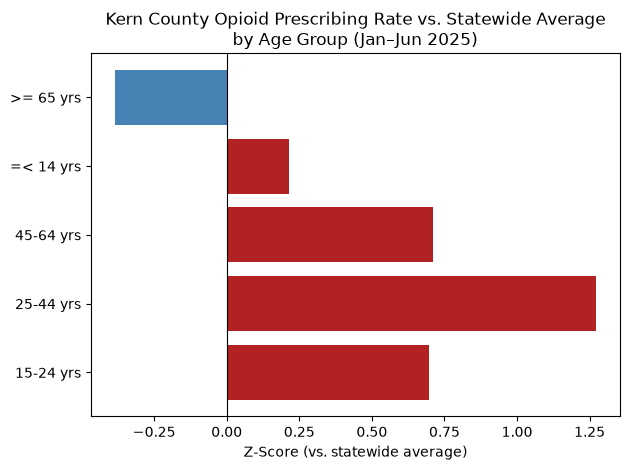

In [24]:
colors = ['firebrick' if z > 0 else 'steelblue' for z in kern_avg.values]

fig, ax = plt.subplots()
ax.barh(kern_avg.index, kern_avg.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Z-Score (vs. statewide average)')
ax.set_title('Kern County Opioid Prescribing Rate vs. Statewide Average\nby Age Group (Jan–Jun 2025)')
plt.tight_layout()
plt.show()

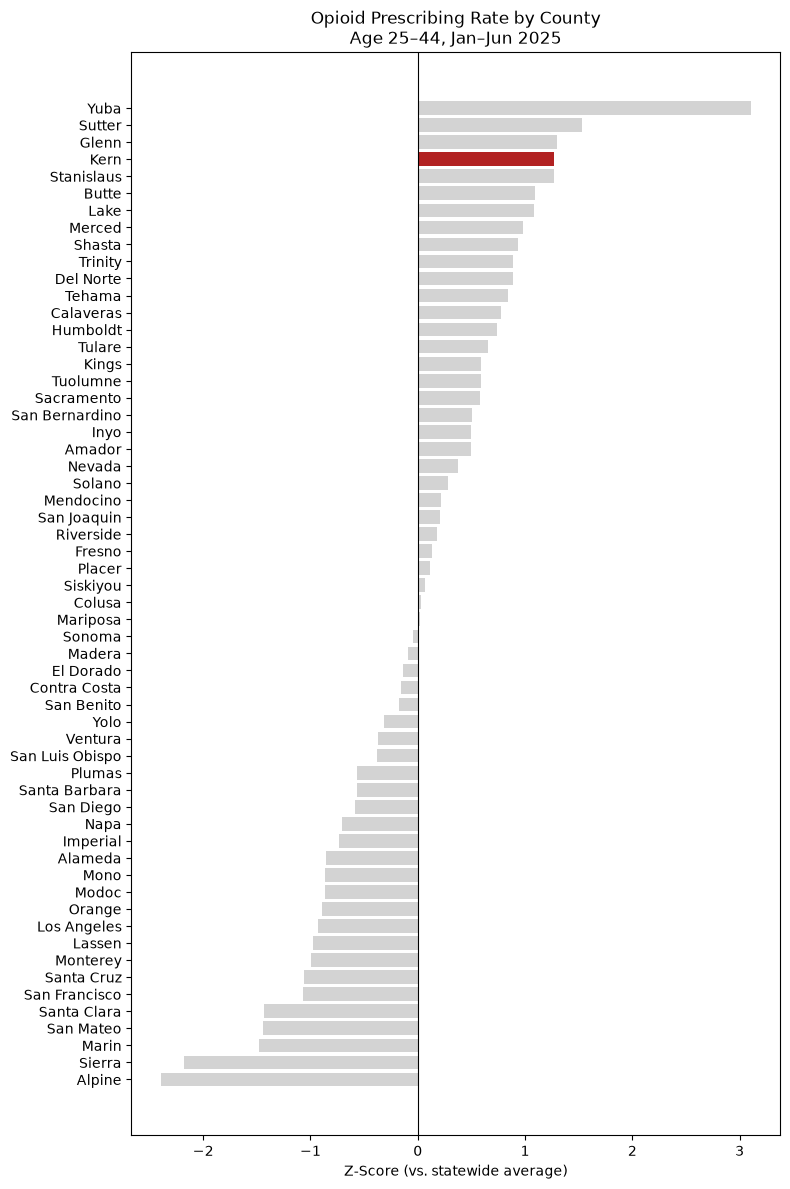

In [25]:
county_avg = df[df['Age_Group'] == '25-44 yrs'].groupby('County')['z_score'].mean().sort_values()

colors = ['firebrick' if c == 'Kern' else 'lightgray' for c in county_avg.index]

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(county_avg.index, county_avg.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Z-Score (vs. statewide average)')
ax.set_title('Opioid Prescribing Rate by County\nAge 25–44, Jan–Jun 2025')
plt.tight_layout()
plt.show()

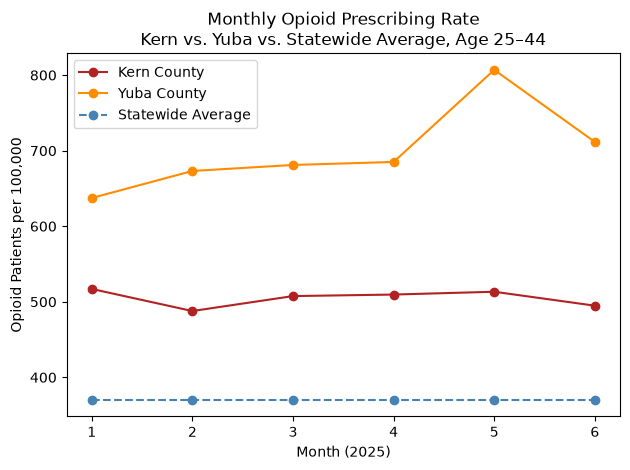

In [26]:
monthly_rates = df[df['Age_Group'] == '25-44 yrs'].groupby(['xMonth', 'County'])['opioid_rate_per_100k'].mean().reset_index()

kern_trend = monthly_rates[monthly_rates['County'] == 'Kern']
yuba_trend = monthly_rates[monthly_rates['County'] == 'Yuba']
state_trend = df[df['Age_Group'] == '25-44 yrs'].groupby('xMonth')['statewide_mean'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(kern_trend['xMonth'], kern_trend['opioid_rate_per_100k'], marker='o', label='Kern County', color='firebrick')
ax.plot(yuba_trend['xMonth'], yuba_trend['opioid_rate_per_100k'], marker='o', label='Yuba County', color='darkorange')
ax.plot(state_trend['xMonth'], state_trend['statewide_mean'], marker='o', label='Statewide Average', color='steelblue', linestyle='--')
ax.set_xlabel('Month (2025)')
ax.set_ylabel('Opioid Patients per 100,000')
ax.set_title('Monthly Opioid Prescribing Rate\nKern vs. Yuba vs. Statewide Average, Age 25–44')
ax.legend()
plt.tight_layout()
plt.show()

1. After completing some exploratory analysis on the data, I found that Adults in Kern County aged 25-44 were prescribed opioids at a significantly higher rate than the state average. Interestingly enough, Adults 65 or older in Kern county were actually prescribed opioids at a lower rate than the state average. Among the 25-44 age group, Kern county was the 4th highest prescribed county for opioids in California, while Yuba county came in first as an extreme outlier. It appears that Kern County's monthly averages in this age range were consistent for the months collected in the data. Yuba County experienced a notable spike in opioid patients per 100,000 people during the month of May 2025. 

2. These findings are significant because we should be attempting to ensure that opioids are only prescribed to patients who truly need them. While they can be helpful, Opioids also carry many adverse affects and can cause dependency, addiction, and overdose among patients. It is important to ensure there are proper controls and checks in place to prevent any diversion or unnecessary dispensing of opioids, as the adverse effects can lead to other problems in our local community. 

3. Recommended next steps in this investigation would be to extend the analysis using the CURES annual dataset, which is available back to 2019, to identify when Kern County's rate for the 25–44 age group first diverged from the statewide trend. Perhaps there may be a specific time where the average in Kern County spiked up to what it is today in this age range and that could lead to a root cause analysis for that time from. It may also be due to environmental factors, as there is a large blue collar population in Kern County and many of them may have injuries and discomfort from hard labor. This may be why there is a dropoff once they are 65 or older, because they may be retired and no longer in pain or discomfort from doing hard labor. 